# Tugas - Klasifikasi dengan Decision Tree

| Nama | NRP |
| --- | --- |
| Catherine Aprilia Harlina | 5054251012 |

# 1. Persiapan Dataset dan Eksplorasi Awal

### Ringkasan Informasi Dataset

| Metrik                  | Nilai                            |
|:------------------------|:---------------------------------|
| Jumlah Baris (Records)  | 6,819                            |
| Jumlah Kolom (Features) | 96                               |
| Total Missing Value     | 0                                |
| Status Missing Value    | Bersih (Tidak Ada Missing Value) |

### Distribusi Kelas Target (Bankrupt?)

| Kelas Kebangkrutan   |   Jumlah Perusahaan | Persentase   |
|:---------------------|--------------------:|:-------------|
| 0 (Tidak Bangkrut)   |                6599 | 96.77%       |
| 1 (Bangkrut)         |                 220 | 3.23%        |

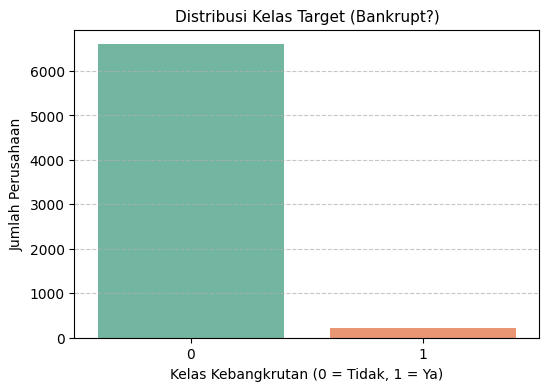

Catatan: Dataset tergolong imbalanced karena 96.77% data berada pada kelas 0 (Tidak Bangkrut).


### Sampel Statistik Deskriptif (5 Fitur Pertama)

,count,mean,std,min,25%,50%,75%,max
ROA(C) before interest and depreciation before interest,6819.0,0.5052,0.0607,0.0,0.4765,0.5027,0.5356,1.0
ROA(A) before interest and % after tax,6819.0,0.5586,0.0656,0.0,0.5355,0.5598,0.5892,1.0
ROA(B) before interest and depreciation after tax,6819.0,0.5536,0.0616,0.0,0.5273,0.5523,0.5841,1.0
Operating Gross Margin,6819.0,0.6079,0.0169,0.0,0.6004,0.6060,0.6139,1.0
Realized Sales Gross Margin,6819.0,0.6079,0.0169,0.0,0.6004,0.6060,0.6138,1.0


### Distribusi Fitur Finansial per Kelas Target (Boxplot)

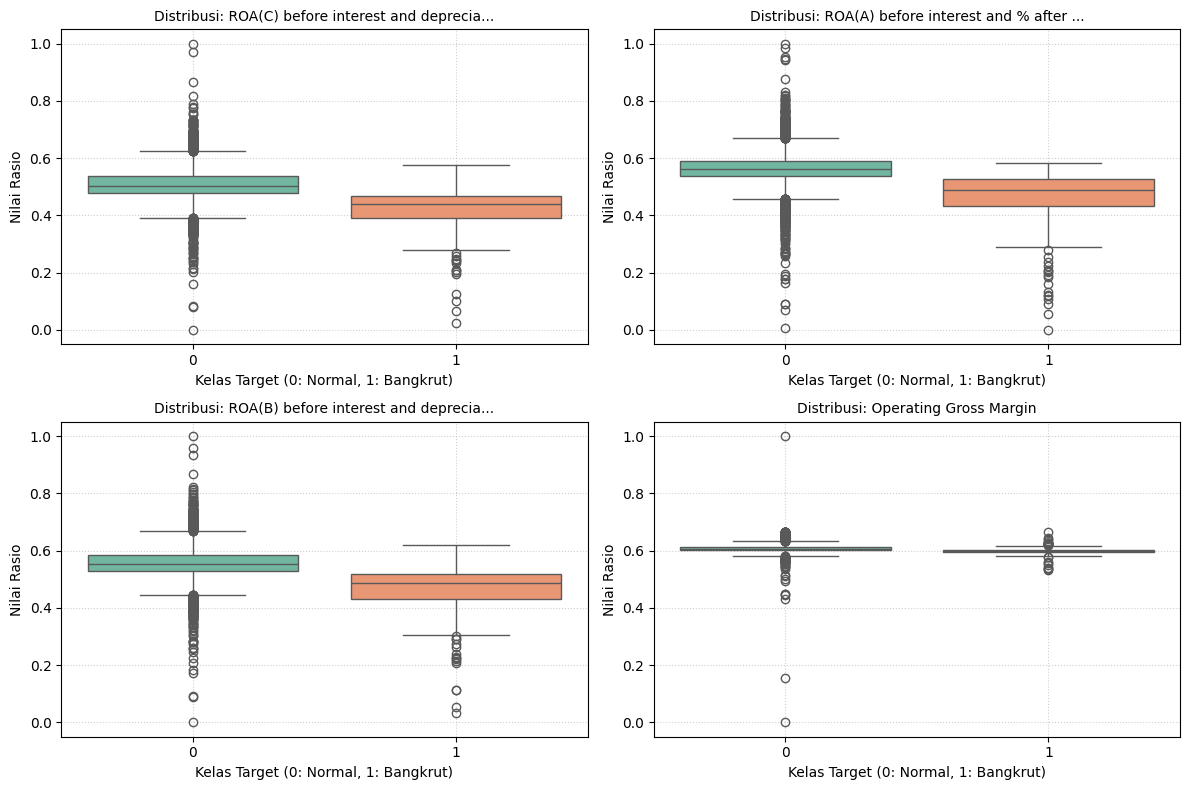

### EDA Tambahan: Top 10 Fitur Paling Berkorelasi dengan Kebangkrutan

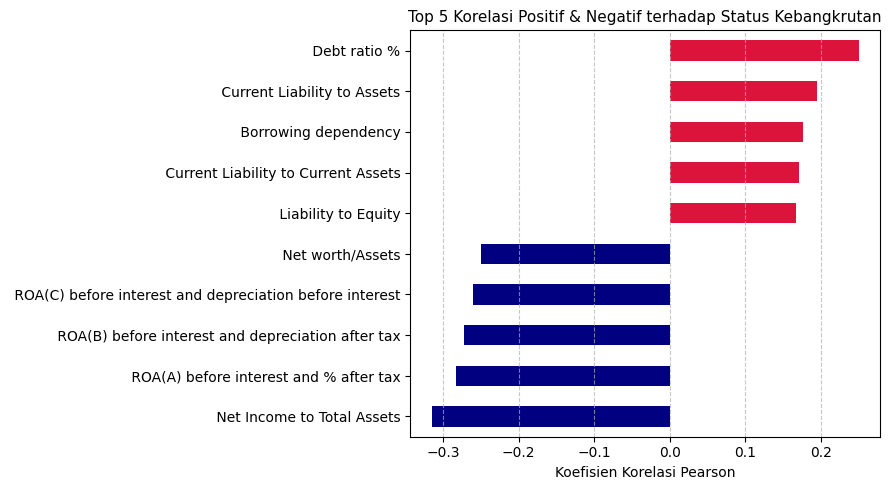

### EDA Tambahan: Ringkasan Outlier pada 5 Fitur Utama (Metode IQR)

| Fitur                                 |   Jumlah Outlier | Persentase Outlier   |
|:--------------------------------------|-----------------:|:---------------------|
| ROA(C) before interest and depreci... |              391 | 5.73%                |
| ROA(A) before interest and % after... |              561 | 8.23%                |
| ROA(B) before interest and depreci... |              432 | 6.34%                |
| Operating Gross Margin                |              320 | 4.69%                |
| Realized Sales Gross Margin           |              318 | 4.66%                |

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from IPython.display import display, Markdown

# Load dataset
df = pd.read_csv('bankruptcy.csv')

# Identifikasi kolom target
target_col = [col for col in df.columns if 'bankrupt' in col.lower()]
target_col = target_col[0] if len(target_col) > 0 else df.columns[0]

# --- 1. RINGKASAN DATASET ---
display(Markdown("### Ringkasan Informasi Dataset"))

info_ringkas = pd.DataFrame({
    'Metrik': ['Jumlah Baris (Records)', 'Jumlah Kolom (Features)', 'Total Missing Value', 'Status Missing Value'],
    'Nilai': [f"{df.shape[0]:,}", f"{df.shape[1]}", f"{df.isnull().sum().sum()}", 'Bersih (Tidak Ada Missing Value)']
})
display(Markdown(info_ringkas.to_markdown(index=False)))

# --- 2. CEK SEBARAN & ANALISIS IMBALANCED DATA ---
display(Markdown("### Distribusi Kelas Target (Bankrupt?)"))

counts = df[target_col].value_counts()
percentages = df[target_col].value_counts(normalize=True) * 100

df_distribusi = pd.DataFrame({
    'Kelas Kebangkrutan': ['0 (Tidak Bangkrut)', '1 (Bangkrut)'],
    'Jumlah Perusahaan': [counts.get(0, 0), counts.get(1, 0)],
    'Persentase': [f"{percentages.get(0, 0):.2f}%", f"{percentages.get(1, 0):.2f}%"]
})
display(Markdown(df_distribusi.to_markdown(index=False)))

# Visualisasi Bar Plot Target
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, hue=target_col, palette='Set2', legend=False)
plt.title(f'Distribusi Kelas Target ({target_col})', fontsize=11)
plt.xlabel('Kelas Kebangkrutan (0 = Tidak, 1 = Ya)')
plt.ylabel('Jumlah Perusahaan')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(f"Catatan: Dataset tergolong imbalanced karena {percentages.get(0, 0):.2f}% data berada pada kelas 0 (Tidak Bangkrut).")

# --- 3. DOKUMENTASI FITUR & STATISTIK DESKRIPTIF (SAMPEL 5 FITUR UTAMA) ---
display(Markdown("### Sampel Statistik Deskriptif (5 Fitur Pertama)"))
display(df.iloc[:, 1:6].describe().T.round(4))

# --- 4. VISUALISASI DISTRIBUSI FITUR DIBEDAKAN KELAS TARGET ---
display(Markdown("### Distribusi Fitur Finansial per Kelas Target (Boxplot)"))

feature_cols = [col for col in df.columns if col != target_col][:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x=target_col, y=col, hue=target_col, palette='Set2', ax=axes[i], legend=False)
    title_clean = col.strip()
    if len(title_clean) > 35:
        title_clean = title_clean[:35] + '...'
    axes[i].set_title(f'Distribusi: {title_clean}', fontsize=10)
    axes[i].set_xlabel('Kelas Target (0: Normal, 1: Bangkrut)')
    axes[i].set_ylabel('Nilai Rasio')
    axes[i].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

# --- 5. EDA TAMBAHAN: KORELASI & OUTLIER ---
display(Markdown("### EDA Tambahan: Top 10 Fitur Paling Berkorelasi dengan Kebangkrutan"))

correlations = df.corr()[target_col].drop(target_col)
top_pos = correlations.nlargest(5)
top_neg = correlations.nsmallest(5)
top_corr = pd.concat([top_pos, top_neg]).sort_values()

plt.figure(figsize=(9, 5))
top_corr.plot(kind='barh', color=['crimson' if x > 0 else 'navy' for x in top_corr])
plt.title('Top 5 Korelasi Positif & Negatif terhadap Status Kebangkrutan', fontsize=11)
plt.xlabel('Koefisien Korelasi Pearson')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

display(Markdown("### EDA Tambahan: Ringkasan Outlier pada 5 Fitur Utama (Metode IQR)"))

def detect_outliers_iqr(dataframe, features):
    outlier_list = []
    for col in features:
        Q1 = dataframe[col].quantile(0.25)
        Q3 = dataframe[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)]
        outlier_count = len(outliers)
        outlier_pct = (outlier_count / len(dataframe)) * 100
        
        outlier_list.append({
            'Fitur': col[:35] + '...' if len(col) > 35 else col,
            'Jumlah Outlier': outlier_count,
            'Persentase Outlier': f"{outlier_pct:.2f}%"
        })
    return pd.DataFrame(outlier_list)

sample_features = [col for col in df.columns if col != target_col][:5]
df_outliers = detect_outliers_iqr(df, sample_features)
display(Markdown(df_outliers.to_markdown(index=False)))

In [7]:
from sklearn.model_selection import train_test_split

# 1. Penanganan Missing Value
# Mengecek kembali jika ada missing value, lalu menangani dengan dropna jika ada
if df.isnull().sum().sum() > 0:
    df = df.dropna()
    print("Missing value ditemukan dan telah dibersihkan.")
else:
    print("Konfirmasi: Dataset bersih, tidak ada missing value yang perlu ditangani.")

# 2. Pengecekan Fitur Kategorikal (Encoding)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

if len(categorical_cols) > 0:
    print(f"Ditemukan {len(categorical_cols)} fitur kategorikal: {categorical_cols}")
    # Lakukan One-Hot Encoding jika ada fitur kategorikal
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
else:
    print("Konfirmasi: Semua fitur dalam dataset sudah berupa numerik (float64/int64), tidak memerlukan encoding tambahan.")

# 3. Pemisahan Fitur (X) dan Target (y)
X = df.drop(columns=[target_col])
y = df[target_col]

# 4. Pembagian Data Train & Test (80:20) dengan Stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# 5. Tampilkan Ringkasan Hasil Preprocessing
display(Markdown("### Ringkasan Pembagian Dataset (Train vs Test)"))

df_split_summary = pd.DataFrame({
    'Dataset': ['Train Set (80%)', 'Test Set (20%)', 'Total Data'],
    'Jumlah Sampel': [f"{X_train.shape[0]:,}", f"{X_test.shape[0]:,}", f"{df.shape[0]:,}"],
    'Jumlah Fitur (X)': [X_train.shape[1], X_test.shape[1], X.shape[1]],
    'Proporsi Target 0 (%)': [
        f"{(y_train == 0).mean() * 100:.2f}%",
        f"{(y_test == 0).mean() * 100:.2f}%",
        f"{(y == 0).mean() * 100:.2f}%"
    ],
    'Proporsi Target 1 (%)': [
        f"{(y_train == 1).mean() * 100:.2f}%",
        f"{(y_test == 1).mean() * 100:.2f}%",
        f"{(y == 1).mean() * 100:.2f}%"
    ]
})

display(Markdown(df_split_summary.to_markdown(index=False)))


Konfirmasi: Dataset bersih, tidak ada missing value yang perlu ditangani.
Konfirmasi: Semua fitur dalam dataset sudah berupa numerik (float64/int64), tidak memerlukan encoding tambahan.


### Ringkasan Pembagian Dataset (Train vs Test)

| Dataset         |   Jumlah Sampel |   Jumlah Fitur (X) | Proporsi Target 0 (%)   | Proporsi Target 1 (%)   |
|:----------------|----------------:|-------------------:|:------------------------|:------------------------|
| Train Set (80%) |           5,455 |                 95 | 96.77%                  | 3.23%                   |
| Test Set (20%)  |           1,364 |                 95 | 96.77%                  | 3.23%                   |
| Total Data      |           6,819 |                 95 | 96.77%                  | 3.23%                   |

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Inisialisasi dan latih model DecisionTreeClassifier dengan criterion='gini'
model_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
model_gini.fit(X_train, y_train)

# 2. Lakukan prediksi pada test set
y_pred_gini = model_gini.predict(X_test)

# 3. Tampilkan informasi pelatihan & akurasi singkat
acc_gini_train = accuracy_score(y_train, model_gini.predict(X_train))
acc_gini_test = accuracy_score(y_test, y_pred_gini)

df_gini_res = pd.DataFrame({
    'Model': ['Decision Tree (Gini)'],
    'Akurasi Training': [f"{acc_gini_train * 100:.2f}%"],
    'Akurasi Testing': [f"{acc_gini_test * 100:.2f}%"],
    'Kedalaman Pohon (Depth)': [model_gini.get_depth()],
    'Jumlah Node': [model_gini.get_n_leaves()]
})

display(Markdown(df_gini_res.to_markdown(index=False)))

| Model                | Akurasi Training   | Akurasi Testing   |   Kedalaman Pohon (Depth) |   Jumlah Node |
|:---------------------|:-------------------|:------------------|--------------------------:|--------------:|
| Decision Tree (Gini) | 100.00%            | 96.11%            |                        20 |           124 |